# BERT Fake News Detector — Базовий експеримент

## Три архітектури класифікаційних голів на базі mBERT:
- **Head A**: `[CLS] → Dropout → Linear(768→2)`
- **Head B**: `[CLS] → Linear(768→512) → BatchNorm → ReLU → Dropout → Linear(512→2)`
- **Head C**: `AttentionPooling → Linear(768→256) → LayerNorm → ReLU → Dropout → Linear(256→2)`

### Ключові параметри:
- MAX_LEN = 256, BATCH_SIZE = 8 (6GB VRAM)
- DROPOUT = 0.4, LR = 1e-5, WEIGHT_DECAY = 0.01
- Gradient Clipping max_norm=1.0
- Збереження найкращої моделі за val_f1

## 1. Імпорти та налаштування

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

# Налаштування
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Device: {device}')

# Очищення VRAM перед стартом
import gc
torch.cuda.empty_cache()
gc.collect()

PyTorch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
Device: cuda


109

## 2. Гіперпараметри

In [ ]:
# Шляхи
DATA_PATH   = r'C:\Users\igrew\OneDrive\Desktop\Course Work\Datasets\news_detector\FINAL_DATASET.csv'
MODELS_DIR  = 'models'
PLOTS_DIR   = 'plots'
RESULTS_DIR = 'results'

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f'Датасет не знайдено: {DATA_PATH}'

# Модель
MODEL_NAME  = 'bert-base-multilingual-cased'
MAX_LEN     = 256
BATCH_SIZE  = 16       
NUM_EPOCHS  = 3
LEARNING_RATE = 1e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
DROPOUT_RATE  = 0.4
GRADIENT_CLIP = 1.0
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Гіперпараметри:')
print(f'  MAX_LEN={MAX_LEN} | BATCH_SIZE={BATCH_SIZE} | EPOCHS={NUM_EPOCHS}')
print(f'  LR={LEARNING_RATE} | DROPOUT={DROPOUT_RATE} | CLIP={GRADIENT_CLIP}')

Гіперпараметри:
  MAX_LEN=256 | BATCH_SIZE=16 | EPOCHS=3
  LR=1e-05 | DROPOUT=0.4 | CLIP=1.0


## 3. Завантаження та аналіз датасету

Розмір датасету: (21738, 2)
Колонки: ['text', 'label']

Розподіл міток:
label
0    10869
1    10869
Name: count, dtype: int64


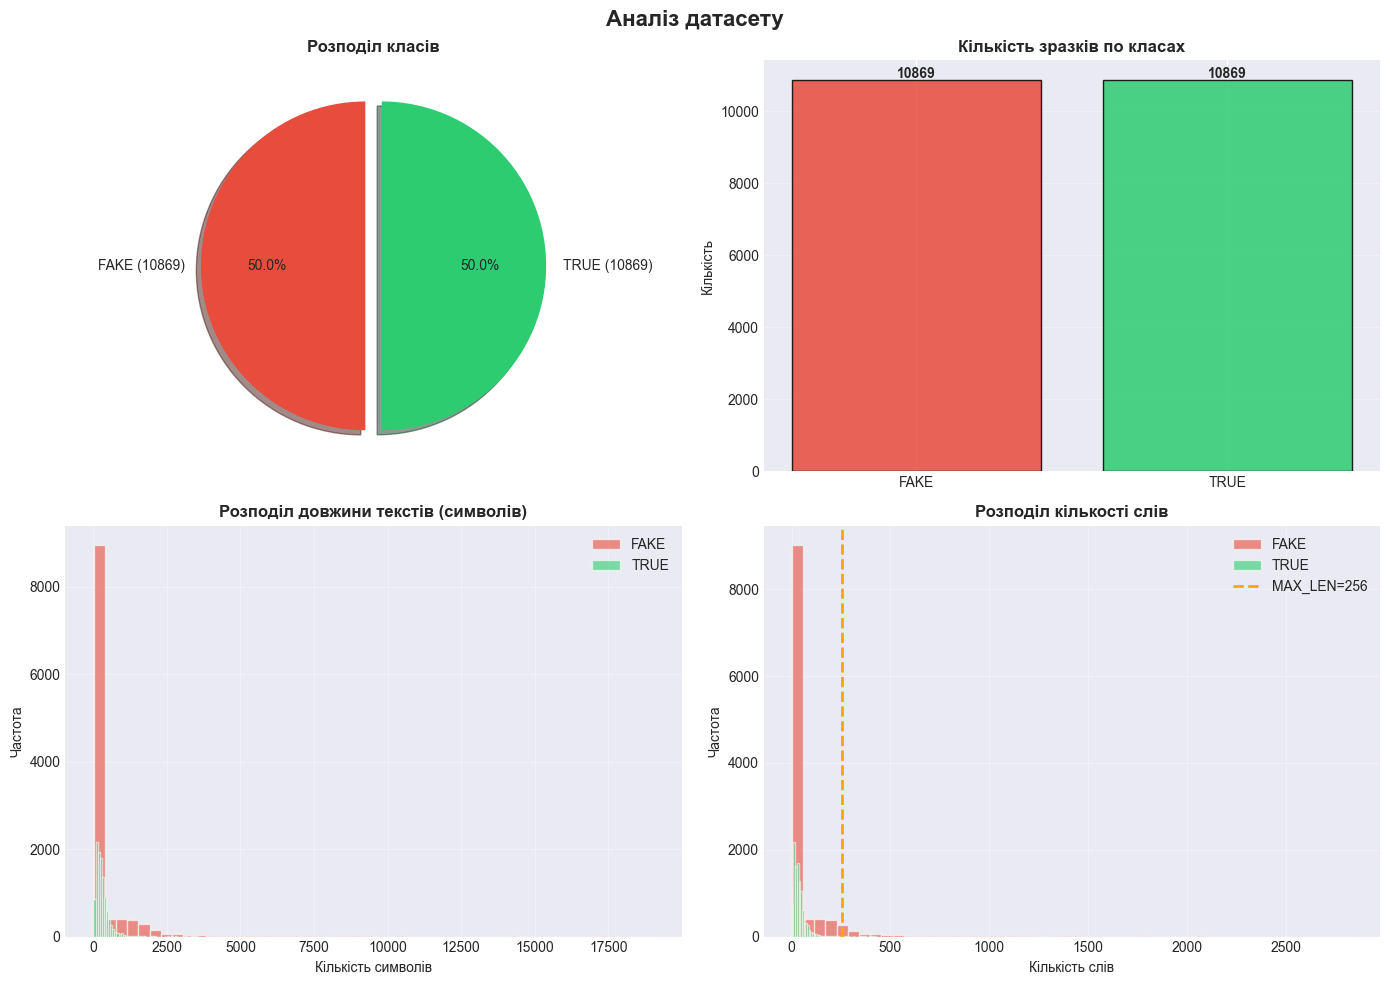


Текстів довших за 256 слів: 2.5%
       text_len  word_count
count   21738.0     21738.0
mean      337.4        46.4
std       685.9        95.3
min         1.0         1.0
25%        85.0        12.0
50%       163.0        22.0
75%       321.0        43.0
max     19044.0      2835.0


In [3]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['text', 'label'])

print(f'Розмір датасету: {df.shape}')
print(f'Колонки: {list(df.columns)}')
print(f'\nРозподіл міток:')
print(df['label'].value_counts())

fake_count = (df['label'] == 0).sum()
true_count = (df['label'] == 1).sum()

# Аналіз довжини текстів
df['text_len']   = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Аналіз датасету', fontsize=16, fontweight='bold')

# Pie
axes[0,0].pie([fake_count, true_count],
              labels=[f'FAKE ({fake_count})', f'TRUE ({true_count})'],
              colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%',
              startangle=90, explode=(0.05,0.05), shadow=True)
axes[0,0].set_title('Розподіл класів', fontweight='bold')

# Bar
axes[0,1].bar(['FAKE','TRUE'], [fake_count, true_count],
              color=['#e74c3c','#2ecc71'], edgecolor='black', alpha=0.85)
axes[0,1].set_title('Кількість зразків по класах', fontweight='bold')
axes[0,1].set_ylabel('Кількість')
for i,v in enumerate([fake_count, true_count]):
    axes[0,1].text(i, v+50, str(v), ha='center', fontweight='bold')
axes[0,1].grid(axis='y', alpha=0.3)

# Довжина символів
for label, color, name in [(0,'#e74c3c','FAKE'),(1,'#2ecc71','TRUE')]:
    axes[1,0].hist(df[df['label']==label]['text_len'], bins=50,
                   alpha=0.6, color=color, label=name, edgecolor='white')
axes[1,0].set_title('Розподіл довжини текстів (символів)', fontweight='bold')
axes[1,0].set_xlabel('Кількість символів')
axes[1,0].set_ylabel('Частота')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Кількість слів
for label, color, name in [(0,'#e74c3c','FAKE'),(1,'#2ecc71','TRUE')]:
    axes[1,1].hist(df[df['label']==label]['word_count'], bins=50,
                   alpha=0.6, color=color, label=name, edgecolor='white')
axes[1,1].axvline(x=256, color='orange', linestyle='--', linewidth=2, label='MAX_LEN=256')
axes[1,1].set_title('Розподіл кількості слів', fontweight='bold')
axes[1,1].set_xlabel('Кількість слів')
axes[1,1].set_ylabel('Частота')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'dataset_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

pct_over = (df['word_count'] > 256).mean() * 100
print(f'\nТекстів довших за 256 слів: {pct_over:.1f}%')
print(df[['text_len','word_count']].describe().round(1))

## 4. Split та токенізація

In [4]:
X = df['text'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train:      {len(X_train):>6} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation: {len(X_val):>6} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test:       {len(X_test):>6} ({len(X_test)/len(X)*100:.1f}%)')

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'\nТокенізатор: {type(tokenizer).__name__}')
print(f'Розмір словника: {tokenizer.vocab_size:,}')

Train:       15216 (70.0%)
Validation:   3261 (15.0%)
Test:         3261 (15.0%)

Токенізатор: BertTokenizer
Розмір словника: 119,547


In [5]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])
        enc   = self.tokenizer(
            text, max_length=self.max_len,
            padding='max_length', truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long)
        }

train_dataset = NewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = NewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = NewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_loader)} батчів × {BATCH_SIZE} = {len(train_dataset)} зразків')
print(f'Val:   {len(val_loader)} батчів')
print(f'Test:  {len(test_loader)} батчів')

Train: 951 батчів × 16 = 15216 зразків
Val:   204 батчів
Test:  204 батчів


## 5. Архітектури моделей

In [6]:
# HEAD A — Baseline: [CLS] → Dropout → Linear
class BertClassifierHeadA(nn.Module):
    def __init__(self, bert_model_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.bert       = BertModel.from_pretrained(bert_model_name)
        hidden          = self.bert.config.hidden_size  # 768
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls    = out.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls))

# HEAD B — MLP + BatchNorm: [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)
class BertClassifierHeadB(nn.Module):
    def __init__(self, bert_model_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.bert       = BertModel.from_pretrained(bert_model_name)
        hidden          = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)

# HEAD C — Attention Pooling: всі токени → зважена сума → LayerNorm → Dropout → Linear
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states).squeeze(-1)
        scores  = scores.masked_fill(attention_mask == 0, float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (hidden_states * weights).sum(dim=1)

class BertClassifierHeadC(nn.Module):
    def __init__(self, bert_model_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.bert          = BertModel.from_pretrained(bert_model_name)
        hidden             = self.bert.config.hidden_size
        self.attention_pool = AttentionPooling(hidden)
        self.classifier    = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.attention_pool(out.last_hidden_state, attention_mask)
        return self.classifier(pooled)

print('Архітектури визначено:')
print('  Head A: BERT → [CLS] → Dropout → Linear(768→2)')
print('  Head B: BERT → [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)')
print('  Head C: BERT → AttPool → Linear(768→256) → LN → ReLU → Dropout → Linear(256→2)')

Архітектури визначено:
  Head A: BERT → [CLS] → Dropout → Linear(768→2)
  Head B: BERT → [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)
  Head C: BERT → AttPool → Linear(768→256) → LN → ReLU → Dropout → Linear(256→2)


## 6. Функції тренування та оцінки

In [7]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, train_loader, val_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps  = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'train_f1':[], 'val_f1':[]}
    best_val_f1   = 0
    best_path     = os.path.join(MODELS_DIR, f'bert_fake_{model_name.lower()}_best.pt')

    print(f'\nТренування {model_name}...')
    print(f'   Кроків warmup: {warmup_steps} / {total_steps}')
    print('=' * 75)
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Val F1":>6}')
    print('=' * 75)

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        flag = ''
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_path)
            flag = ' ✓ SAVED'

        delta = val_loss - train_loss
        print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>6.4f}  Δ={delta:+.4f}{flag}')

    print('=' * 75)
    print(f'Найкращий Val F1: {best_val_f1:.4f}')
    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_val_f1

print('Функції тренування визначено')

Функції тренування визначено


## 7. Функції візуалізації

In [8]:
def plot_head_results(head_name, history, y_true, y_pred, y_prob, metrics):
    """Всі графіки для однієї голови: loss, accuracy, confusion matrix, ROC, delta"""
    epochs = range(1, len(history['train_loss']) + 1)
    colors = {'A': ('#3498db','#85c1e9'), 'B': ('#e74c3c','#f1948a'), 'C': ('#2ecc71','#82e0aa')}
    letter = head_name[-1]
    c_dark, c_light = colors.get(letter, ('#3498db','#85c1e9'))

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Результати {head_name}', fontsize=16, fontweight='bold')

    # 1. Loss
    axes[0,0].plot(epochs, history['train_loss'], 'o-', color=c_dark,  label='Train', linewidth=2)
    axes[0,0].plot(epochs, history['val_loss'],   's--', color=c_light, label='Val',   linewidth=2)
    axes[0,0].set_title('Loss', fontweight='bold')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    # 2. Accuracy
    axes[0,1].plot(epochs, history['train_acc'], 'o-', color=c_dark,  label='Train', linewidth=2)
    axes[0,1].plot(epochs, history['val_acc'],   's--', color=c_light, label='Val',   linewidth=2)
    axes[0,1].set_title('Accuracy', fontweight='bold')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
    axes[0,1].set_ylim([0.5, 1.0]); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    # 3. Delta Val-Train Loss по епохах
    deltas = [v - t for v, t in zip(history['val_loss'], history['train_loss'])]
    bar_colors = ['#e74c3c' if d > 0.05 else '#2ecc71' for d in deltas]
    axes[0,2].bar(epochs, deltas, color=bar_colors, alpha=0.8)
    axes[0,2].axhline(y=0.05, color='orange', linestyle='--', linewidth=1.5, label='Поріг 0.05')
    axes[0,2].axhline(y=0,    color='black',  linestyle='-',  linewidth=0.8)
    for i, (ep, d) in enumerate(zip(epochs, deltas)):
        axes[0,2].text(ep, d + 0.002, f'{d:+.4f}', ha='center', fontsize=9)
    axes[0,2].set_title('Δ Val−Train Loss по епохах', fontweight='bold')
    axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Val Loss − Train Loss')
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3, axis='y')

    # 4. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0], cmap='Blues',
                xticklabels=['FAKE','TRUE'], yticklabels=['FAKE','TRUE'],
                linewidths=1, linecolor='white')
    axes[1,0].set_title(f'Confusion Matrix (Acc={metrics["acc"]:.3f})', fontweight='bold')
    axes[1,0].set_xlabel('Передбачено'); axes[1,0].set_ylabel('Реальне')

    # 5. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1,1].plot(fpr, tpr, color=c_dark, lw=2, label=f'AUC = {metrics["roc_auc"]:.3f}')
    axes[1,1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
    axes[1,1].set_title('ROC Curve', fontweight='bold')
    axes[1,1].set_xlabel('False Positive Rate'); axes[1,1].set_ylabel('True Positive Rate')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    # 6. Метрики bar
    metric_names  = ['Accuracy','F1','Precision','Recall','ROC-AUC']
    metric_values = [metrics['acc'], metrics['f1'], metrics['prec'], metrics['rec'], metrics['roc_auc']]
    bars = axes[1,2].bar(metric_names, metric_values, color=c_dark, alpha=0.8)
    axes[1,2].set_ylim([0, 1.05])
    axes[1,2].set_title('Метрики на тестовій вибірці', fontweight='bold')
    axes[1,2].grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, metric_values):
        axes[1,2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(PLOTS_DIR, f'bert_fake_{head_name.lower()}_results.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Збережено: {save_path}')

print('Функції візуалізації визначено')

Функції візуалізації визначено


## 8. Тренування Head A

In [9]:
torch.cuda.empty_cache(); gc.collect()

print('=' * 60)
print('HEAD A: [CLS] → Dropout → Linear')
print('=' * 60)

model_a = BertClassifierHeadA(MODEL_NAME, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_a.parameters()):,}')

model_a, history_a, best_f1_a = train_model(model_a, train_loader, val_loader, 'HeadA')

HEAD A: [CLS] → Dropout → Linear


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 177,854,978

Тренування HeadA...
   Кроків warmup: 285 / 2853
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.3232 |   0.8480 |   0.2155 |  0.9052 | 0.9050  Δ=-0.1077 ✓ SAVED


     2 |     0.1833 |   0.9265 |   0.1969 |  0.9206 | 0.9205  Δ=+0.0137 ✓ SAVED


     3 |     0.1259 |   0.9479 |   0.2331 |  0.9209 | 0.9209  Δ=+0.1072 ✓ SAVED
Найкращий Val F1: 0.9209



Test Results Head A:
  acc: 0.9243
  f1: 0.9242
  prec: 0.9250
  rec: 0.9243
  roc_auc: 0.9829


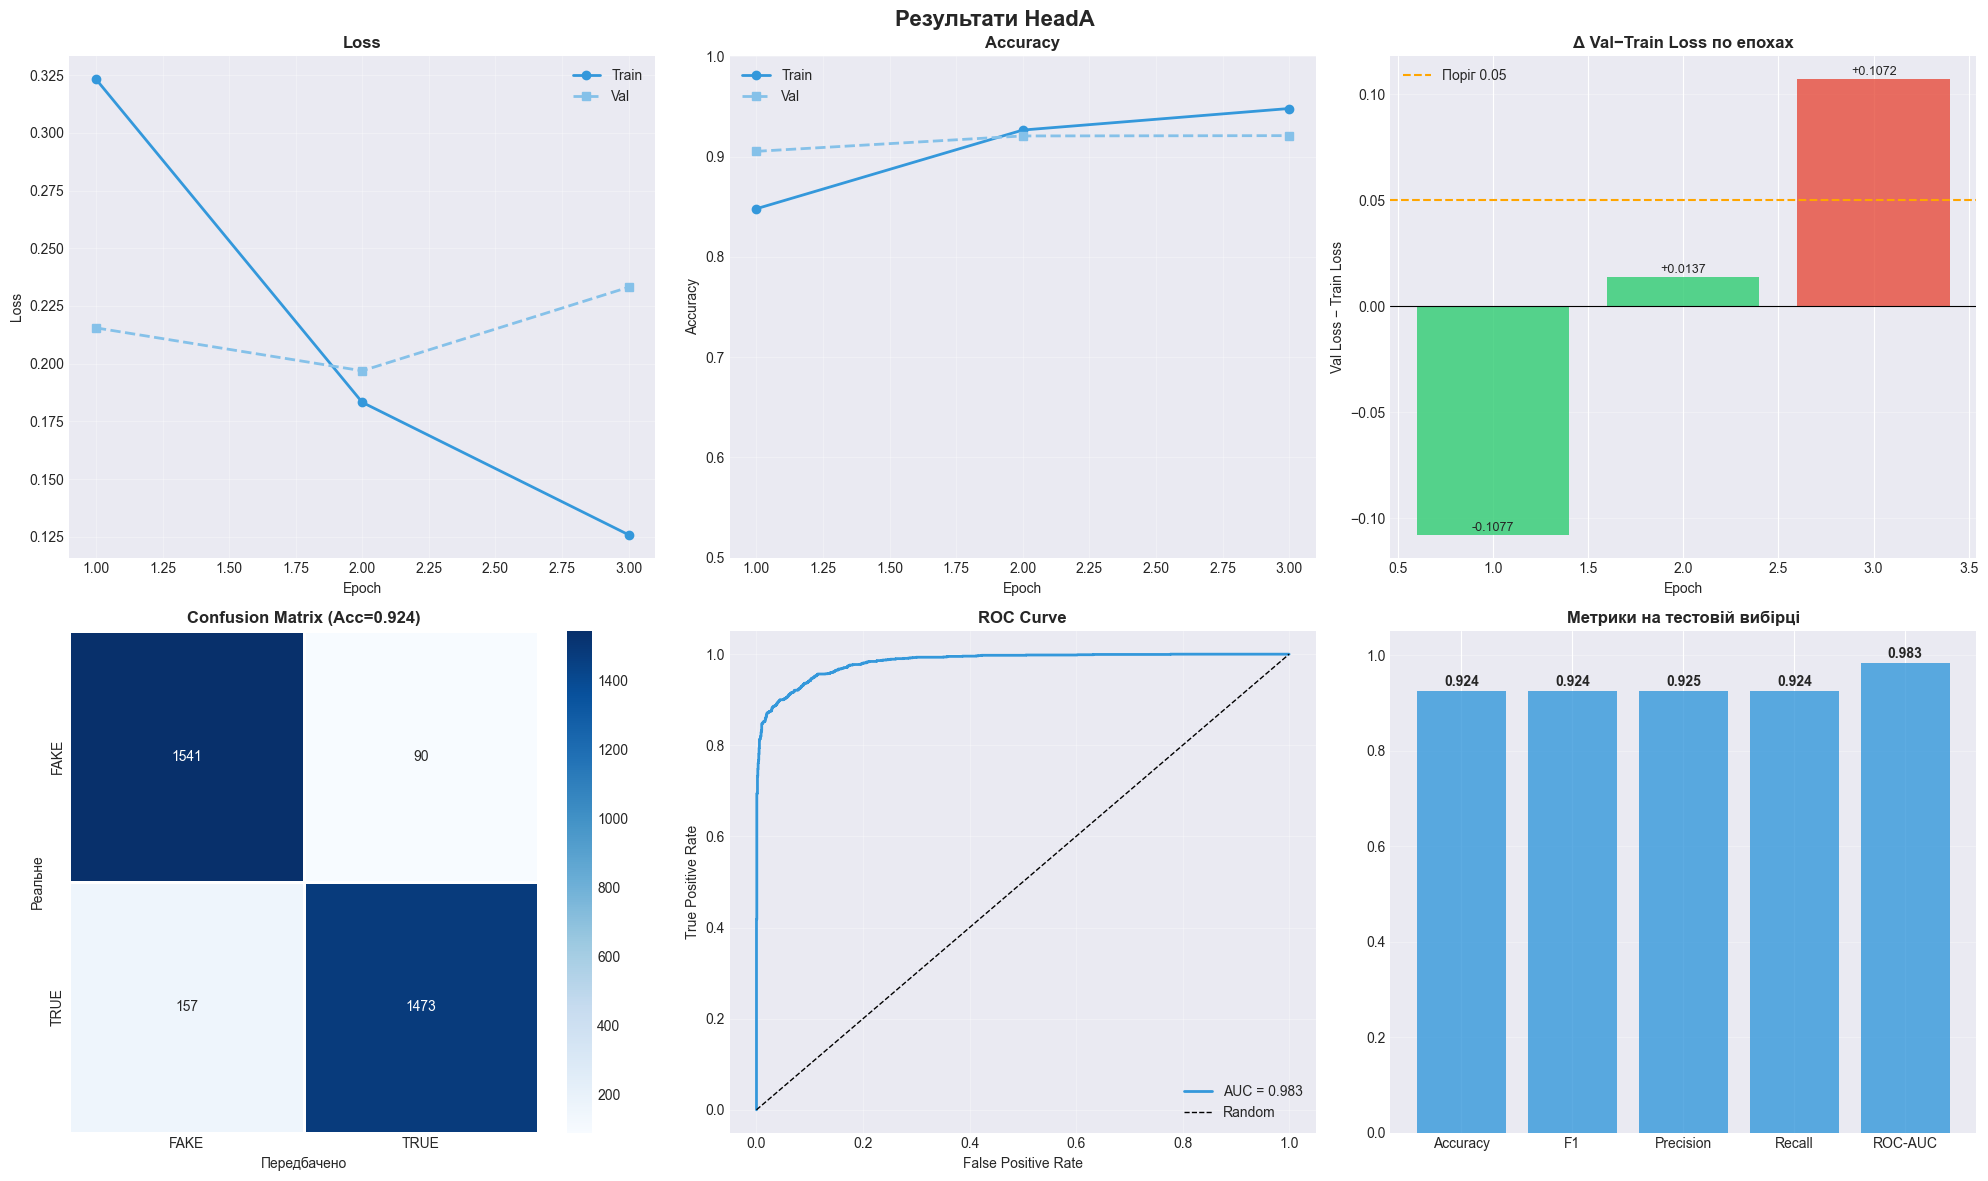

Збережено: plots\bert_fake_heada_results.png


In [10]:
criterion = nn.CrossEntropyLoss()
_, _, _, y_true_a, y_pred_a, y_prob_a = evaluate(model_a, test_loader, criterion)

metrics_a = {
    'acc':     accuracy_score(y_true_a, y_pred_a),
    'f1':      f1_score(y_true_a, y_pred_a, average='weighted'),
    'prec':    precision_score(y_true_a, y_pred_a, average='weighted'),
    'rec':     recall_score(y_true_a, y_pred_a, average='weighted'),
    'roc_auc': roc_auc_score(y_true_a, y_prob_a)
}

print('\nTest Results Head A:')
for k, v in metrics_a.items():
    print(f'  {k}: {v:.4f}')

plot_head_results('HeadA', history_a, y_true_a, y_pred_a, y_prob_a, metrics_a)

## 9. Тренування Head B

In [11]:
torch.cuda.empty_cache(); gc.collect()

print('=' * 60)
print('HEAD B: [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)')
print('=' * 60)

model_b = BertClassifierHeadB(MODEL_NAME, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_b.parameters()):,}')

model_b, history_b, best_f1_b = train_model(model_b, train_loader, val_loader, 'HeadB')

HEAD B: [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 178,249,218

Тренування HeadB...
   Кроків warmup: 285 / 2853
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.3484 |   0.8380 |   0.2012 |  0.9154 | 0.9153  Δ=-0.1472 ✓ SAVED


     2 |     0.1950 |   0.9284 |   0.1899 |  0.9184 | 0.9183  Δ=-0.0051 ✓ SAVED


     3 |     0.1444 |   0.9474 |   0.2299 |  0.9246 | 0.9245  Δ=+0.0855 ✓ SAVED
Найкращий Val F1: 0.9245



Test Results Head B:
  acc: 0.9270
  f1: 0.9269
  prec: 0.9293
  rec: 0.9270
  roc_auc: 0.9823


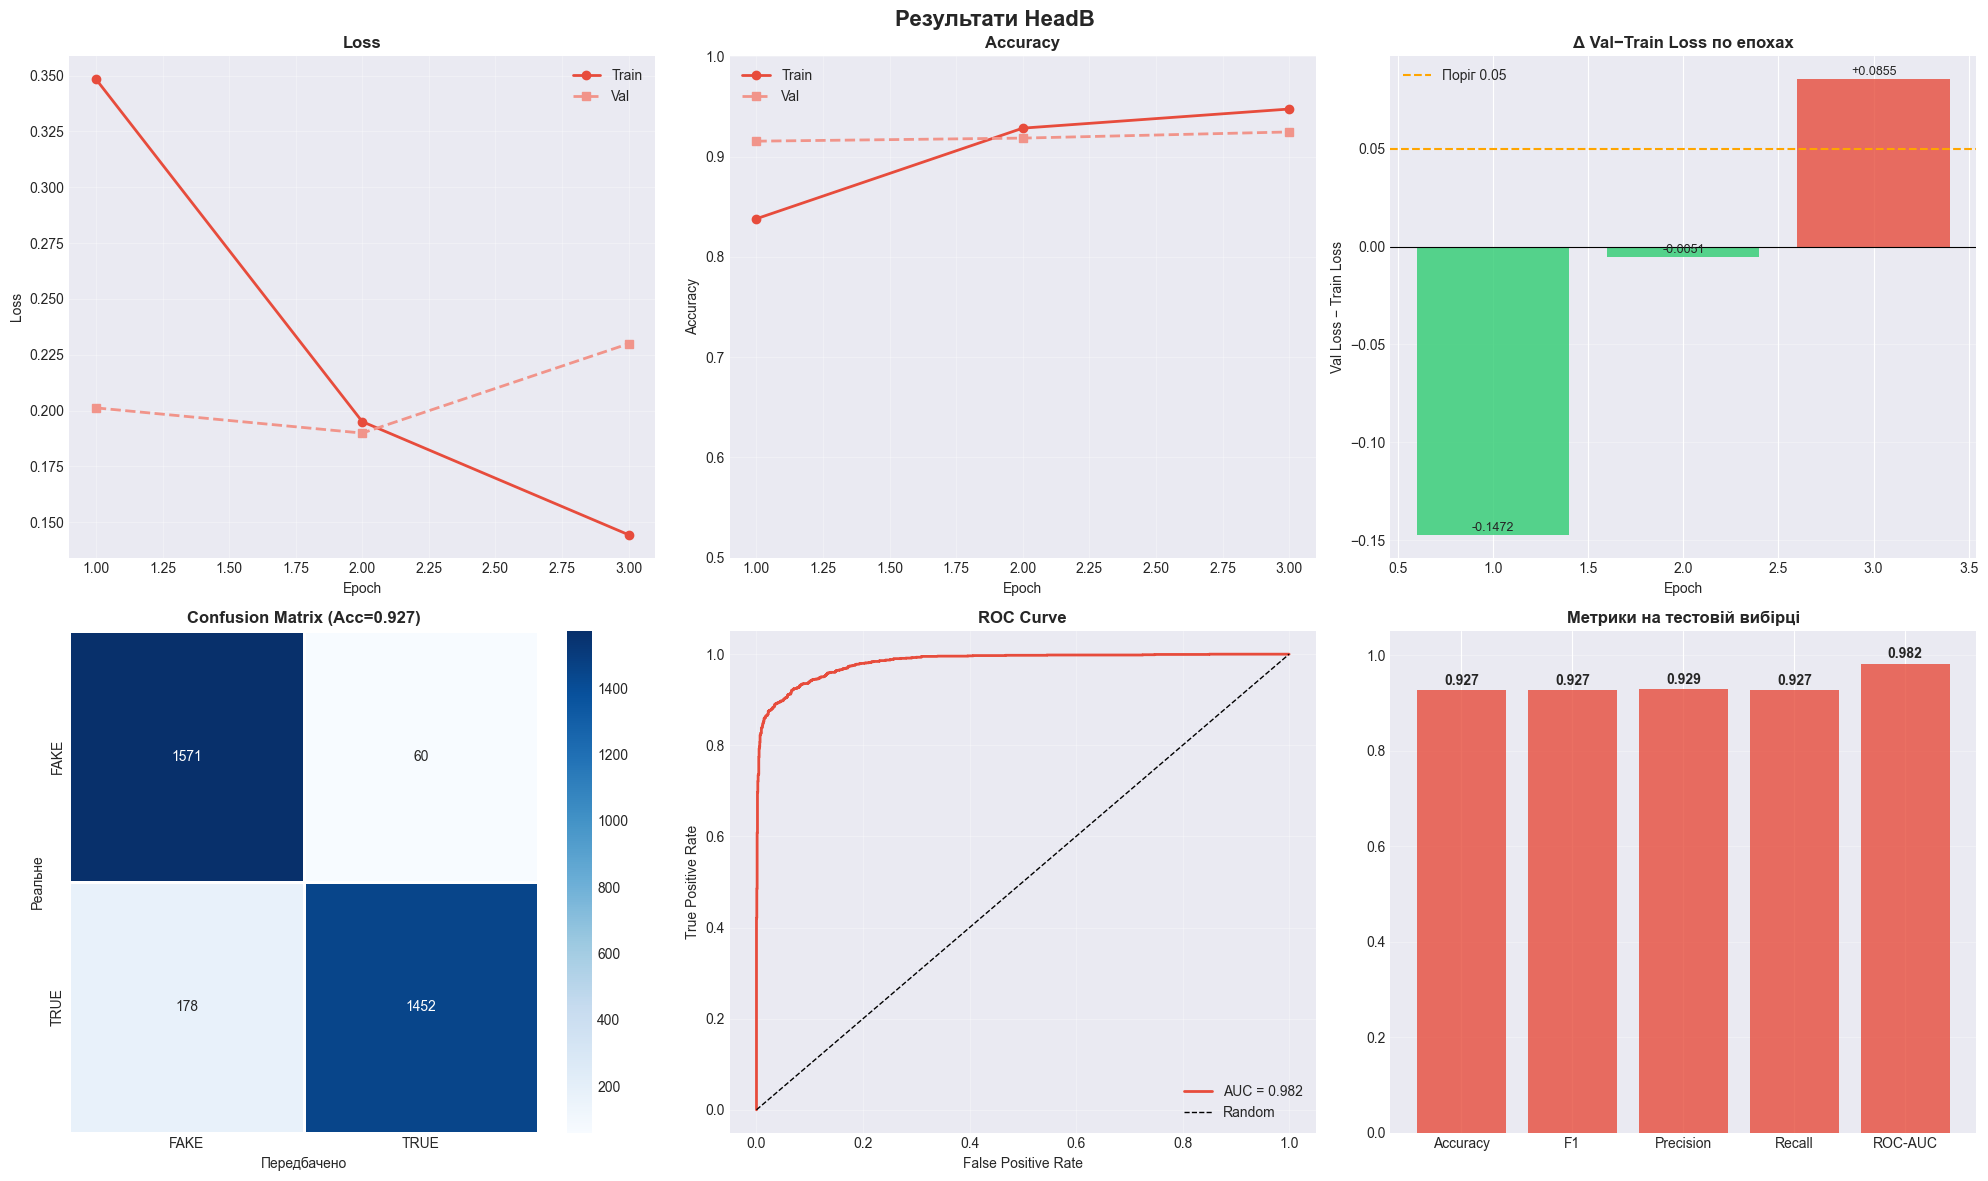

Збережено: plots\bert_fake_headb_results.png


In [12]:
_, _, _, y_true_b, y_pred_b, y_prob_b = evaluate(model_b, test_loader, criterion)

metrics_b = {
    'acc':     accuracy_score(y_true_b, y_pred_b),
    'f1':      f1_score(y_true_b, y_pred_b, average='weighted'),
    'prec':    precision_score(y_true_b, y_pred_b, average='weighted'),
    'rec':     recall_score(y_true_b, y_pred_b, average='weighted'),
    'roc_auc': roc_auc_score(y_true_b, y_prob_b)
}

print('\nTest Results Head B:')
for k, v in metrics_b.items():
    print(f'  {k}: {v:.4f}')

plot_head_results('HeadB', history_b, y_true_b, y_pred_b, y_prob_b, metrics_b)

## 10. Тренування Head C

In [15]:
torch.cuda.empty_cache(); gc.collect()

print('=' * 60)
print('HEAD C: AttentionPooling → Linear(768→256) → LN → ReLU → Dropout → Linear(256→2)')
print('=' * 60)

model_c = BertClassifierHeadC(MODEL_NAME, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_c.parameters()):,}')

model_c, history_c, best_f1_c = train_model(model_c, train_loader, val_loader, 'HeadC')

HEAD C: AttentionPooling → Linear(768→256) → LN → ReLU → Dropout → Linear(256→2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 178,052,099

Тренування HeadC...
   Кроків warmup: 285 / 2853
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.3251 |   0.8507 |   0.2091 |  0.9102 | 0.9097  Δ=-0.1160 ✓ SAVED


     2 |     0.1788 |   0.9300 |   0.1749 |  0.9273 | 0.9273  Δ=-0.0039 ✓ SAVED


     3 |     0.1277 |   0.9474 |   0.2047 |  0.9255 | 0.9254  Δ=+0.0770
Найкращий Val F1: 0.9273



Test Results Head C:
  acc: 0.9295
  f1: 0.9294
  prec: 0.9306
  rec: 0.9295
  roc_auc: 0.9827


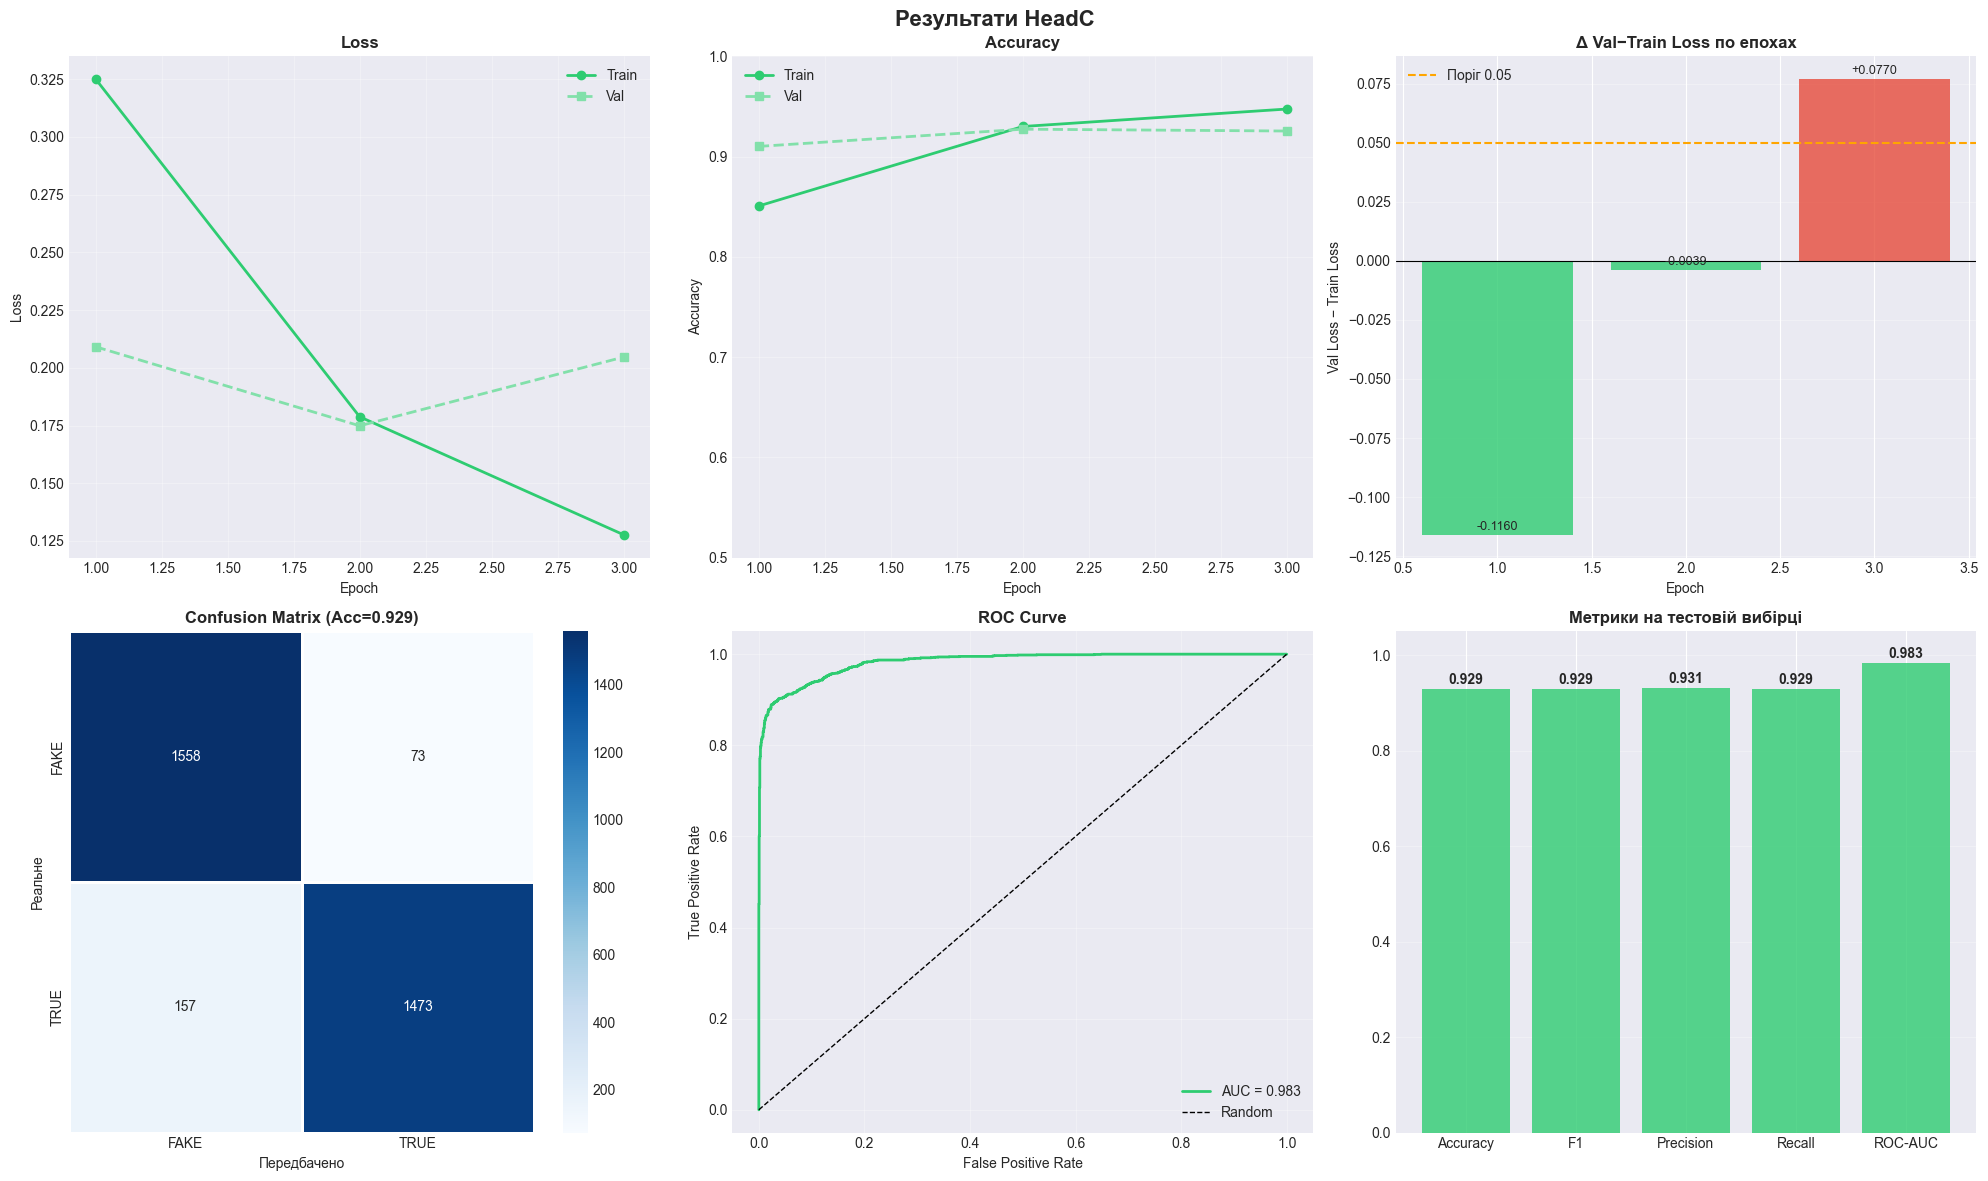

Збережено: plots\bert_fake_headc_results.png


In [16]:
_, _, _, y_true_c, y_pred_c, y_prob_c = evaluate(model_c, test_loader, criterion)

metrics_c = {
    'acc':     accuracy_score(y_true_c, y_pred_c),
    'f1':      f1_score(y_true_c, y_pred_c, average='weighted'),
    'prec':    precision_score(y_true_c, y_pred_c, average='weighted'),
    'rec':     recall_score(y_true_c, y_pred_c, average='weighted'),
    'roc_auc': roc_auc_score(y_true_c, y_prob_c)
}

print('\nTest Results Head C:')
for k, v in metrics_c.items():
    print(f'  {k}: {v:.4f}')

plot_head_results('HeadC', history_c, y_true_c, y_pred_c, y_prob_c, metrics_c)

## 11. Порівняння всіх голів

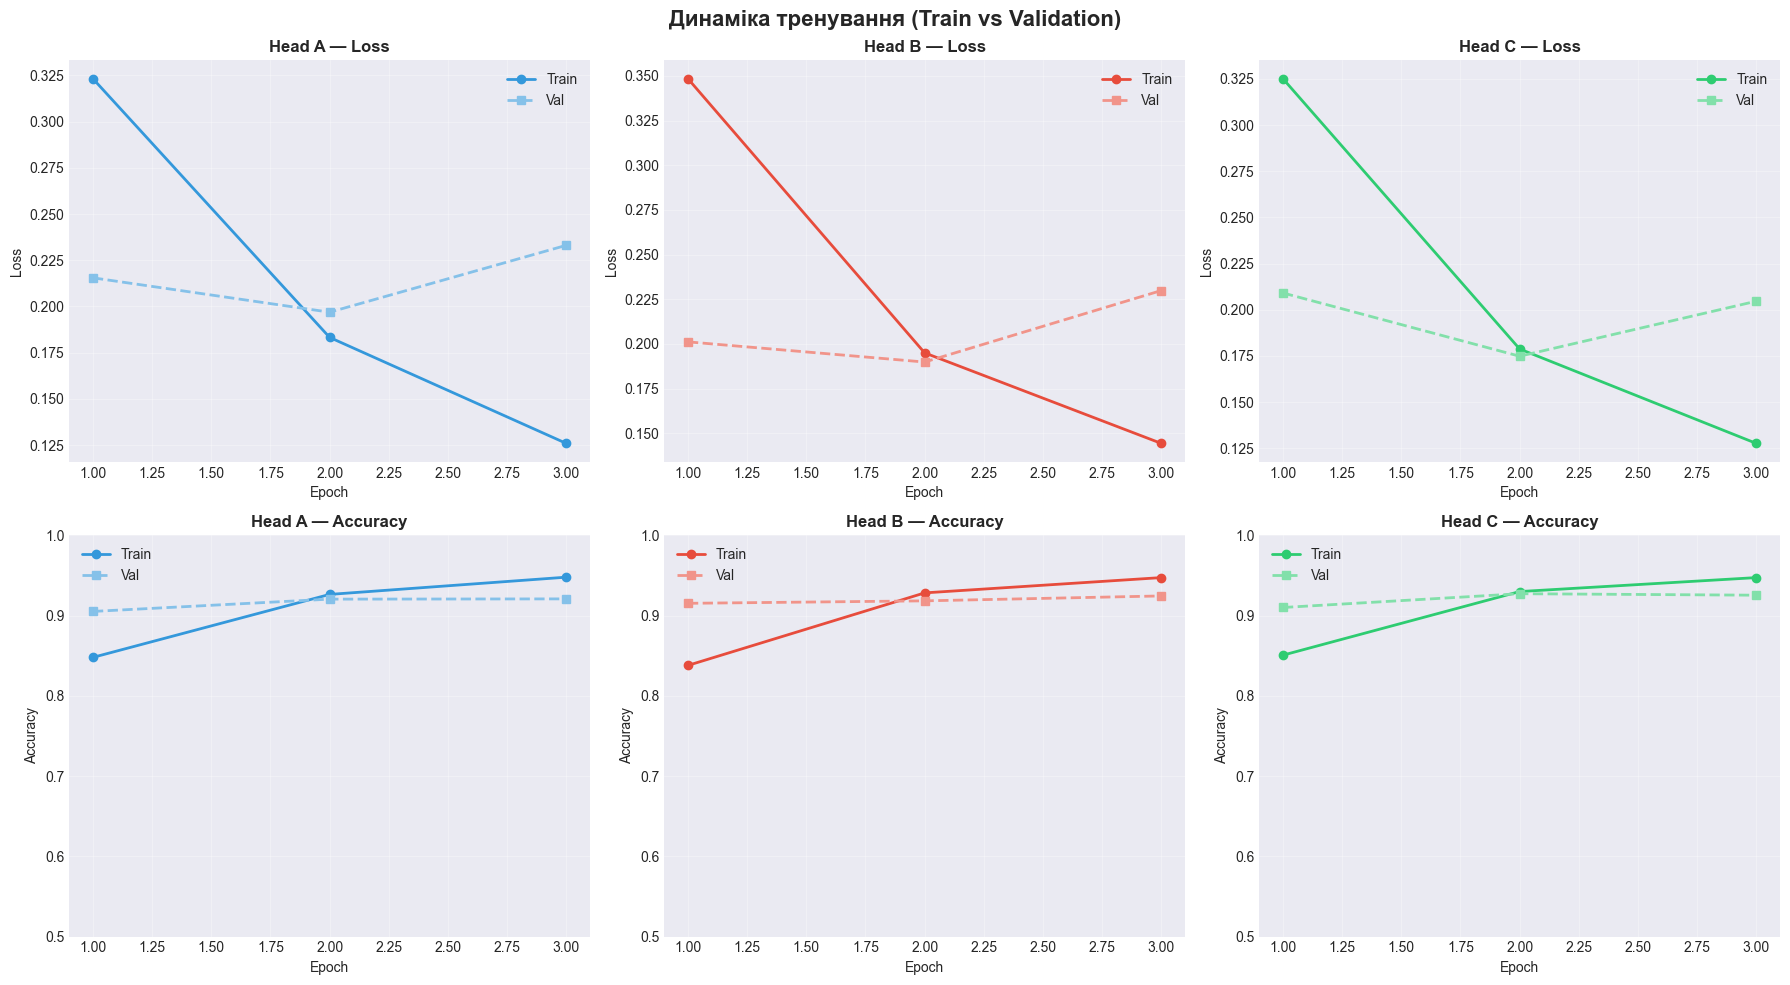

In [17]:
# Val Loss всіх трьох голів на одному графіку
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Динаміка тренування (Train vs Validation)', fontsize=16, fontweight='bold')

colors_map = {
    'Head A': ('#3498db','#85c1e9'),
    'Head B': ('#e74c3c','#f1948a'),
    'Head C': ('#2ecc71','#82e0aa')
}

for col, (name, history) in enumerate([
    ('Head A', history_a), ('Head B', history_b), ('Head C', history_c)
]):
    c_dark, c_light = colors_map[name]
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0][col].plot(epochs, history['train_loss'], 'o-', color=c_dark,  label='Train', linewidth=2)
    axes[0][col].plot(epochs, history['val_loss'],   's--', color=c_light, label='Val',   linewidth=2)
    axes[0][col].set_title(f'{name} — Loss', fontweight='bold')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Loss')
    axes[0][col].legend(); axes[0][col].grid(alpha=0.3)

    axes[1][col].plot(epochs, history['train_acc'], 'o-', color=c_dark,  label='Train', linewidth=2)
    axes[1][col].plot(epochs, history['val_acc'],   's--', color=c_light, label='Val',   linewidth=2)
    axes[1][col].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Accuracy')
    axes[1][col].set_ylim([0.5, 1.0]); axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bert_fake_all_heads_training.png'), dpi=150, bbox_inches='tight')
plt.show()

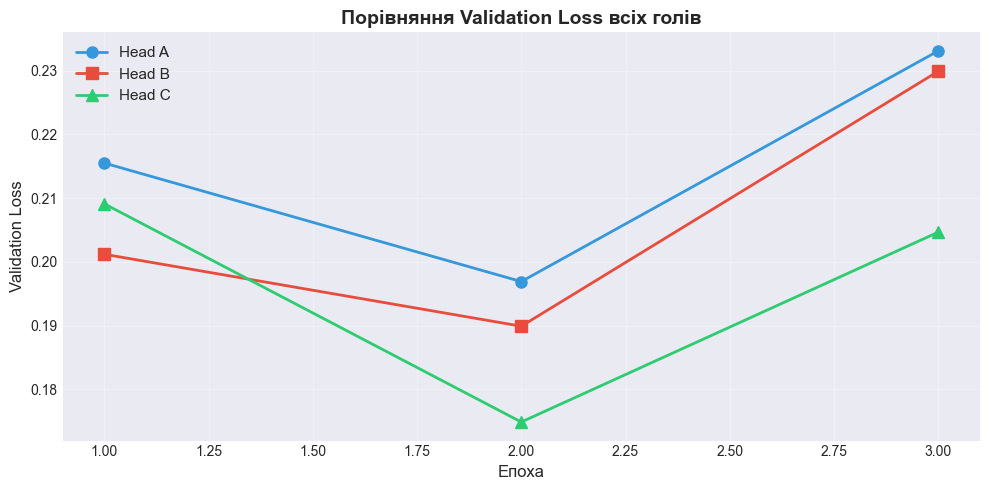

In [18]:
# Val Loss всіх трьох голів на ОДНОМУ графіку
plt.figure(figsize=(10, 5))
epochs = range(1, NUM_EPOCHS + 1)
plt.plot(epochs, history_a['val_loss'], 'o-', color='#3498db', label='Head A', linewidth=2, markersize=8)
plt.plot(epochs, history_b['val_loss'], 's-', color='#e74c3c', label='Head B', linewidth=2, markersize=8)
plt.plot(epochs, history_c['val_loss'], '^-', color='#2ecc71', label='Head C', linewidth=2, markersize=8)
plt.xlabel('Епоха', fontsize=12); plt.ylabel('Validation Loss', fontsize=12)
plt.title('Порівняння Validation Loss всіх голів', fontsize=14, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bert_fake_val_loss_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


ПОРІВНЯННЯ РЕЗУЛЬТАТІВ НА ТЕСТОВОМУ НАБОРІ
Модель                  Accuracy       F1  Precision   Recall  ROC-AUC
--------------------------------------------------------------------------------
Head A (Linear)           0.9243   0.9242     0.9250   0.9243   0.9829
Head B (BN-MLP)           0.9270   0.9269     0.9293   0.9270   0.9823
Head C (AttPool)          0.9295   0.9294     0.9306   0.9295   0.9827


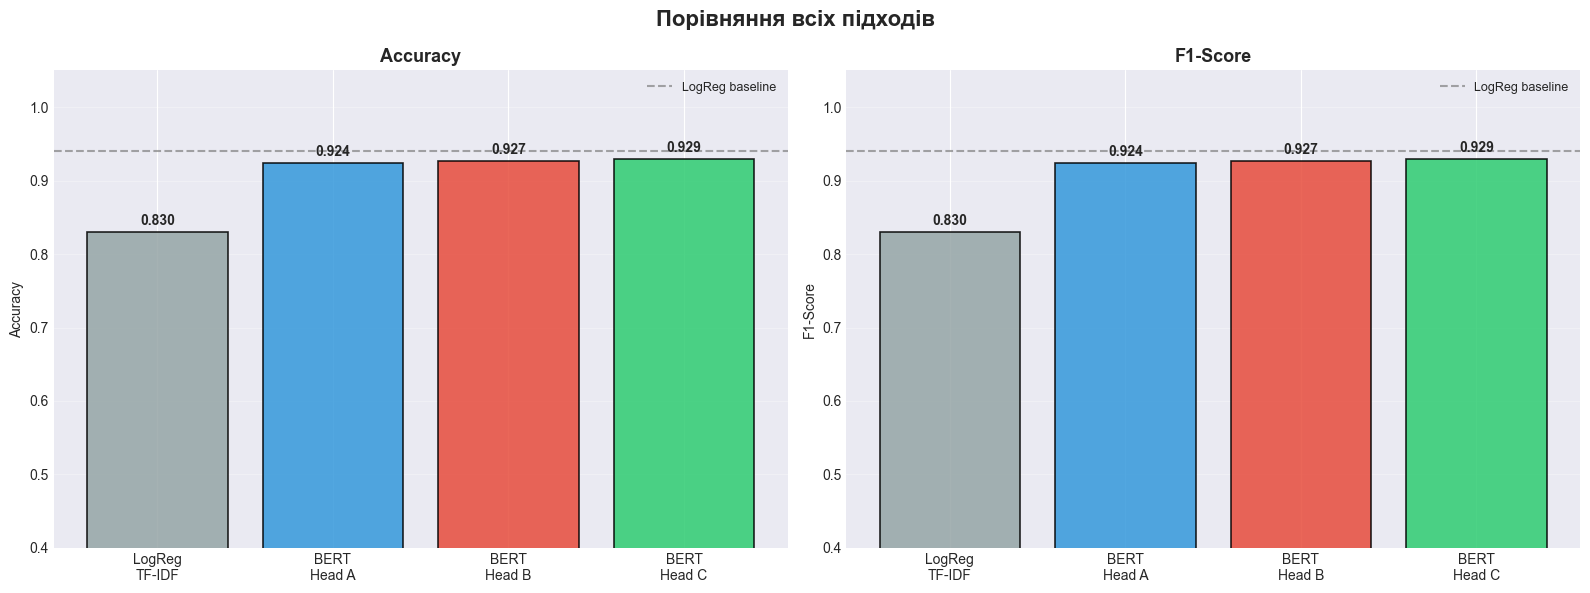

In [21]:
# Зведена таблиця та grouped bar plot
results = {
    'Head A (Linear)':  {**metrics_a, 'y_true': y_true_a, 'y_pred': y_pred_a, 'y_prob': y_prob_a, 'history': history_a},
    'Head B (BN-MLP)':  {**metrics_b, 'y_true': y_true_b, 'y_pred': y_pred_b, 'y_prob': y_prob_b, 'history': history_b},
    'Head C (AttPool)': {**metrics_c, 'y_true': y_true_c, 'y_pred': y_pred_c, 'y_prob': y_prob_c, 'history': history_c},
}

print('\n' + '=' * 80)
print('ПОРІВНЯННЯ РЕЗУЛЬТАТІВ НА ТЕСТОВОМУ НАБОРІ')
print('=' * 80)
print(f'{"Модель":<22} {"Accuracy":>9} {"F1":>8} {"Precision":>10} {"Recall":>8} {"ROC-AUC":>8}')
print('-' * 80)
for name, r in results.items():
    print(f'{name:<22} {r["acc"]:>9.4f} {r["f1"]:>8.4f} {r["prec"]:>10.4f} {r["rec"]:>8.4f} {r["roc_auc"]:>8.4f}')
print('=' * 80)

# Порівняльний grouped bar plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Порівняння всіх підходів', fontsize=16, fontweight='bold')

all_models = {
    'LogReg\nTF-IDF': {'acc': 0.83, 'f1': 0.83},
    'BERT\nHead A':   {'acc': metrics_a['acc'], 'f1': metrics_a['f1']},
    'BERT\nHead B':   {'acc': metrics_b['acc'], 'f1': metrics_b['f1']},
    'BERT\nHead C':   {'acc': metrics_c['acc'], 'f1': metrics_c['f1']},
}
model_names = list(all_models.keys())
bar_colors  = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']

for ax, metric, title in [(axes[0],'acc','Accuracy'), (axes[1],'f1','F1-Score')]:
    values = [v[metric] for v in all_models.values()]
    bars = ax.bar(model_names, values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title); ax.set_ylim([0.4, 1.05])
    ax.axhline(y=0.94, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='LogReg baseline')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bert_fake_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Confusion Matrix + ROC — всі голови

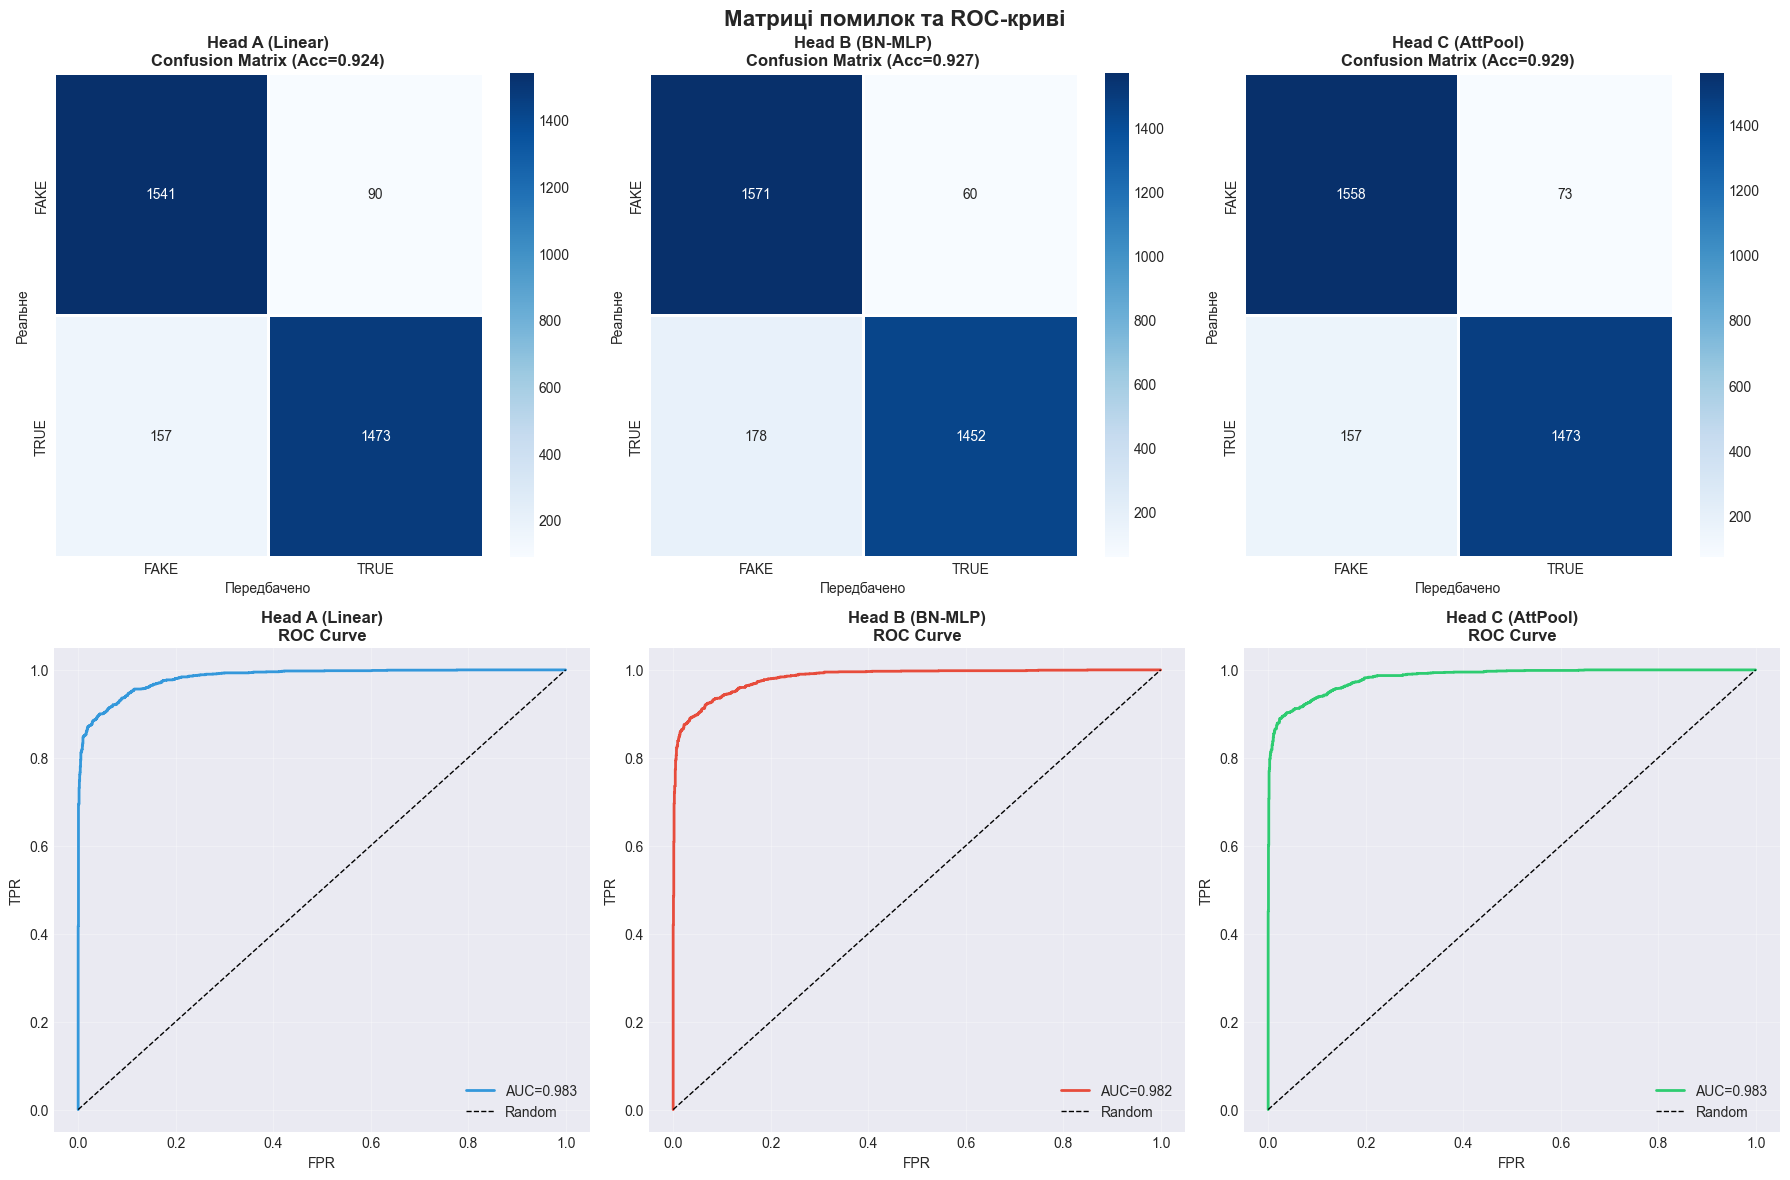

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Матриці помилок та ROC-криві', fontsize=16, fontweight='bold')
colors_list = [('#3498db','Head A (Linear)'), ('#e74c3c','Head B (BN-MLP)'), ('#2ecc71','Head C (AttPool)')]

for col, (color, name) in enumerate(colors_list):
    r = results[name]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0][col], cmap='Blues',
                xticklabels=['FAKE','TRUE'], yticklabels=['FAKE','TRUE'],
                linewidths=1, linecolor='white')
    axes[0][col].set_title(f'{name}\nConfusion Matrix (Acc={r["acc"]:.3f})', fontweight='bold')
    axes[0][col].set_xlabel('Передбачено'); axes[0][col].set_ylabel('Реальне')

    fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
    axes[1][col].plot(fpr, tpr, color=color, lw=2, label=f'AUC={r["roc_auc"]:.3f}')
    axes[1][col].plot([0,1],[0,1], 'k--', lw=1, label='Random')
    axes[1][col].set_title(f'{name}\nROC Curve', fontweight='bold')
    axes[1][col].set_xlabel('FPR'); axes[1][col].set_ylabel('TPR')
    axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bert_fake_confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Збереження моделей та результатів

In [24]:
import json
from datetime import datetime

# Визначення найкращої моделі
best_name  = max(results, key=lambda k: results[k]['f1'])
best_model = {'Head A (Linear)': model_a, 'Head B (BN-MLP)': model_b, 'Head C (AttPool)': model_c}[best_name]

# Збереження найкращої моделі для веб-сайту
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_name':       MODEL_NAME,
    'head_type':        best_name,
    'max_len':          MAX_LEN,
    'test_accuracy':    results[best_name]['acc'],
    'test_f1':          results[best_name]['f1'],
    'hyperparameters':  {
        'max_len': MAX_LEN, 'dropout': DROPOUT_RATE,
        'lr': LEARNING_RATE, 'batch_size': BATCH_SIZE
    }
}, os.path.join(MODELS_DIR, 'bert_fake_detector_best.pt'))

# Збереження токенізатора
tokenizer.save_pretrained(os.path.join(MODELS_DIR, 'bert_tokenizer'))

# Збереження метрик у JSON
name_map = {
    'Head A (Linear)':  '02_bert_fake_headA_results.json',
    'Head B (BN-MLP)':  '02_bert_fake_headB_results.json',
    'Head C (AttPool)': '02_bert_fake_headC_results.json',
}

head_name_map = {
    'Head A (Linear)':  'BERT_HeadA',
    'Head B (BN-MLP)':  'BERT_HeadB',
    'Head C (AttPool)': 'BERT_HeadC',
}

for name, r in results.items():
    metrics_to_save = {
        'timestamp': datetime.now().isoformat(),
        'metrics': {
            'accuracy':  float(r['acc']),
            'precision': float(r['prec']),
            'recall':    float(r['rec']),
            'f1':        float(r['f1']),
            'roc_auc':   float(r['roc_auc'])
        },
        'model_name': head_name_map[name]
    }
    filepath = os.path.join(RESULTS_DIR, name_map[name])
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
    print(f'Збережено: {filepath}')

print('\n' + '=' * 80)
print('ПІДСУМКОВА ТАБЛИЦЯ ВСІХ МОДЕЛЕЙ')
print('=' * 80)
print(f'{"Модель":<35} {"Acc":>7} {"F1":>7} {"Prec":>7} {"Rec":>7} {"AUC":>7}  Статус')
print('-' * 80)
print(f'{"Logistic Regression + TF-IDF":<35} {"~0.84":>7} {"~0.84":>7} {"~0.85":>7} {"~0.81":>7} {"0.92":>7}  Baseline')
for name, r in results.items():
    flag = 'НАЙКРАЩЕ ✓' if name == best_name else ''
    print(f'{"BERT " + name:<35} {r["acc"]:>7.4f} {r["f1"]:>7.4f} {r["prec"]:>7.4f} {r["rec"]:>7.4f} {r["roc_auc"]:>7.4f}  {flag}')
print('=' * 80)
print(f'\nНайкраща архітектура: {best_name}')
print(f'  Accuracy: {results[best_name]["acc"]:.4f}')
print(f'  F1-Score: {results[best_name]["f1"]:.4f}')
print(f'  ROC-AUC:  {results[best_name]["roc_auc"]:.4f}')
print('\nЗбережено:')
print(f'  {MODELS_DIR}/bert_fake_detector_best.pt')
print(f'  {MODELS_DIR}/bert_tokenizer/')
print(f'  {RESULTS_DIR}/bert_fake_base_results.json')

Збережено: results\02_bert_fake_headA_results.json
Збережено: results\02_bert_fake_headB_results.json
Збережено: results\02_bert_fake_headC_results.json

ПІДСУМКОВА ТАБЛИЦЯ ВСІХ МОДЕЛЕЙ
Модель                                  Acc      F1    Prec     Rec     AUC  Статус
--------------------------------------------------------------------------------
Logistic Regression + TF-IDF          ~0.84   ~0.84   ~0.85   ~0.81    0.92  Baseline
BERT Head A (Linear)                 0.9243  0.9242  0.9250  0.9243  0.9829  
BERT Head B (BN-MLP)                 0.9270  0.9269  0.9293  0.9270  0.9823  
BERT Head C (AttPool)                0.9295  0.9294  0.9306  0.9295  0.9827  НАЙКРАЩЕ ✓

Найкраща архітектура: Head C (AttPool)
  Accuracy: 0.9295
  F1-Score: 0.9294
  ROC-AUC:  0.9827

Збережено:
  models/bert_fake_detector_best.pt
  models/bert_tokenizer/
  results/bert_fake_base_results.json
